# Behind the Carts: What Drives People to Buy Online?

![My Picture](https://enniskillen.com/wp-content/uploads/2023/12/GD_Website_Images-62.png)

_Mildred Dzre_


# Project Description


- This project explores the hidden patterns in online shopping behavior to answer a key business question: What factors influence how much customers spend? By analyzing product preferences, discount usage, and purchase habits, we uncover insights that can help e-commerce brands optimize marketing, boost sales, and better understand their customers.

In [72]:
#Importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Loading the Dataset
shop = pd.read_csv("shopping_behaviour.csv")

In [3]:
shop

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [4]:
#checking first 5 rows
shop.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
#checking last five rows
shop.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [6]:
#checking the total rows & columns of the dataset
shop.shape

(3900, 18)

_This dataset has 3,900 rows and 18 columns_

In [8]:
#checking the number of columns
shop.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [9]:
#checking for more information about the dataset
shop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [10]:
#checking for duplicates
shop.duplicated().sum()

0

_There are no duplicates in the dataset_

# DATA CLEANING

In [13]:
# dropping irrelevant columns
shop = shop.drop(columns=['Customer ID', 'Review Rating'])

In [18]:

shop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     3900 non-null   int64 
 1   Gender                  3900 non-null   object
 2   Item Purchased          3900 non-null   object
 3   Category                3900 non-null   object
 4   Purchase Amount (USD)   3900 non-null   int64 
 5   Location                3900 non-null   object
 6   Size                    3900 non-null   object
 7   Color                   3900 non-null   object
 8   Season                  3900 non-null   object
 9   Subscription Status     3900 non-null   object
 10  Shipping Type           3900 non-null   object
 11  Discount Applied        3900 non-null   object
 12  Promo Code Used         3900 non-null   object
 13  Previous Purchases      3900 non-null   int64 
 14  Payment Method          3900 non-null   object
 15  Freq

In [19]:
shop.rename({'Age': 'age'}, axis=1, inplace=True)
shop.rename({'Gender': 'gender'}, axis=1, inplace=True)
shop.rename({'Item Purchased': 'item_purchased'}, axis=1, inplace=True)
shop.rename({'Category': 'category'}, axis=1, inplace=True)
shop.rename({'Purchase Amount (USD)': 'purchase_amount_usd'}, axis=1, inplace=True)
shop.rename({'Location': 'location'}, axis=1, inplace=True)
shop.rename({'Size': 'size'}, axis=1, inplace=True)
shop.rename({'Color': 'color'}, axis=1, inplace=True)
shop.rename({'Season': 'season'}, axis=1, inplace=True)
shop.rename({'Subscription Status': 'subscription_status'}, axis=1, inplace=True)
shop.rename({'Shipping Type': 'shipping_type'}, axis=1, inplace=True)
shop.rename({'Discount Applied': 'discount_applied'}, axis=1, inplace=True)
shop.rename({'Promo Code Used': 'promo_code_used'}, axis=1, inplace=True)
shop.rename({'Previous Purchases': 'previous_purchases'}, axis=1, inplace=True)
shop.rename({'Payment Method': 'payment_method'}, axis=1, inplace=True)
shop.rename({'Frequency of Purchases': 'frequency_of_purchases'}, axis=1, inplace=True)


In [20]:
shop.dtypes

age                        int64
gender                    object
item_purchased            object
category                  object
purchase_amount_usd        int64
location                  object
size                      object
color                     object
season                    object
subscription_status       object
shipping_type             object
discount_applied          object
promo_code_used           object
previous_purchases         int64
payment_method            object
frequency_of_purchases    object
dtype: object

In [21]:
# Changing datatypes
shop['category'] = shop['category'].astype('category')
shop['subscription_status'] = shop['subscription_status'].astype('category')
shop['shipping_type'] = shop['shipping_type'].astype('category')
shop['discount_applied'] = shop['discount_applied'].astype('category')
shop['promo_code_used'] = shop['promo_code_used'].astype('category')
shop['payment_method'] = shop['payment_method'].astype('category')
shop['age'] = shop['age'].astype('object')



In [22]:
shop.isnull().sum()

age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_usd       0
location                  0
size                      0
color                     0
season                    0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

_There are no null values in the dataset_

# VISUALIZATION

In [186]:
custom_colors = ['#211C84', '#4D55CC', '#7A73D1', '#B5A8D5']
sns.set_palette(custom_colors)


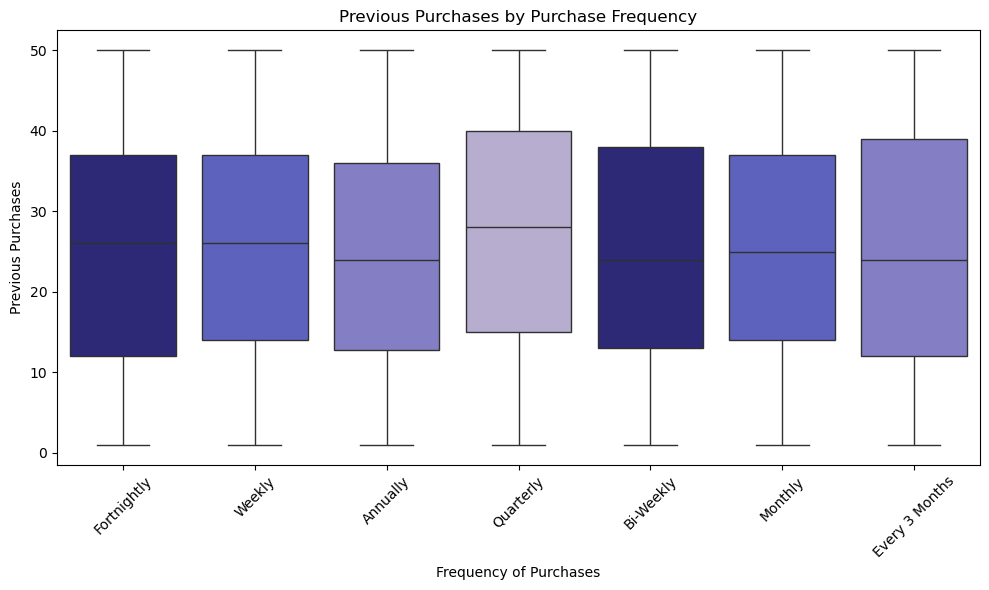

In [188]:
# Make sure your palette is defined
custom_colors = ['#211C84', '#4D55CC', '#7A73D1', '#B5A8D5']

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=shop,
    x='frequency_of_purchases',
    y='previous_purchases',
    palette=custom_colors
)

plt.title('Previous Purchases by Purchase Frequency')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Previous Purchases')  # Added y-axis label
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('previous_by_frequency.png', dpi=300)
plt.show()


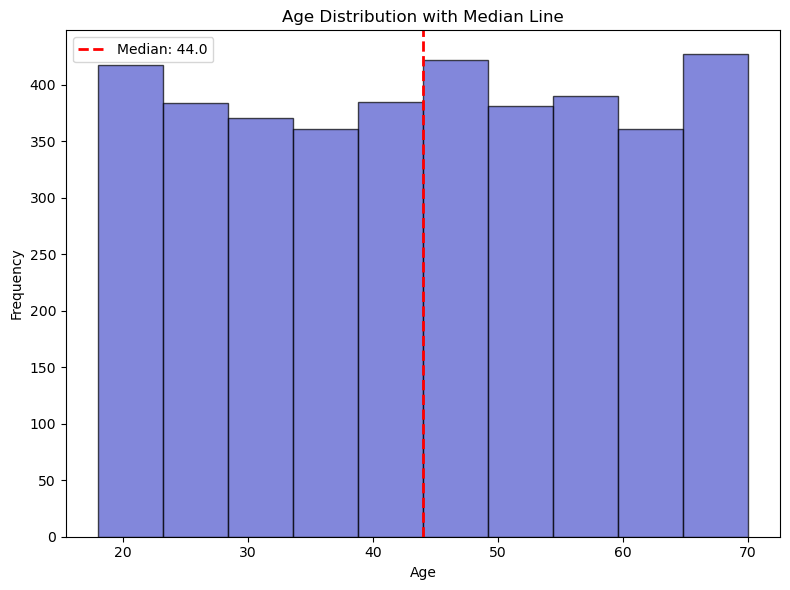

In [183]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure age is numeric
ages = shop['age'].astype(int)
median_age = ages.median()

plt.figure(figsize=(8, 6))
plt.hist(
    ages,
    bins=10,
    color='#4D55CC',
    edgecolor='black',
    alpha=0.7
)

# Median line in red
plt.axvline(
    median_age,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_age}'
)

plt.title('Age Distribution with Median Line')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('age_histogram_median.png', dpi=300)
plt.show()


This indicates no skewness or a symmetric distribution. This means the data is roughly evenly distributed on both sides of the median, and the mean and median would be close to each other in such a case.

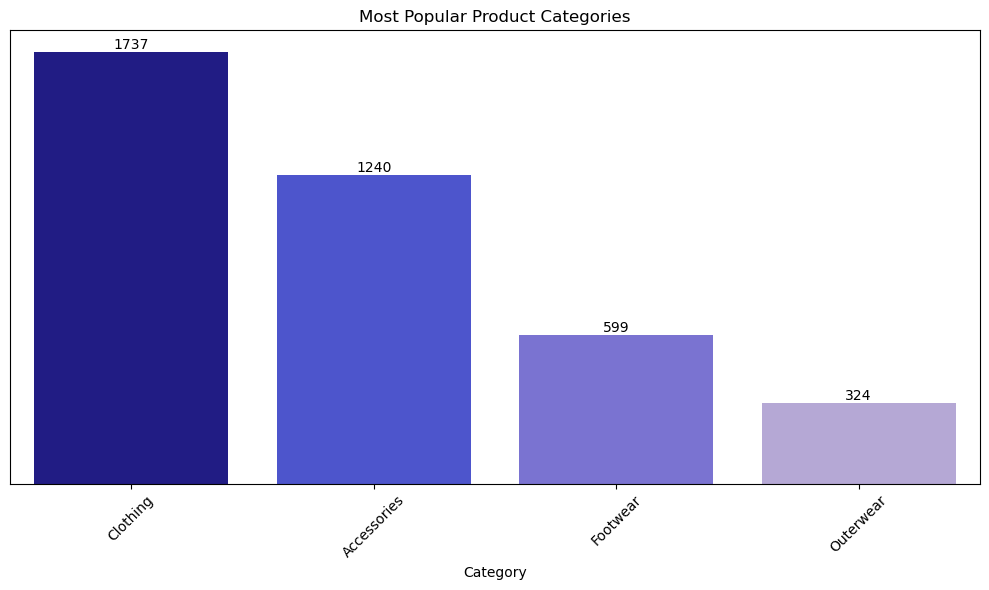

In [38]:
# Custom color palette
custom_colors = ['#211C84', '#4D55CC', '#7A73D1', '#B5A8D5']

# Create the plot
plt.figure(figsize=(10, 6))
order = shop['category'].value_counts().index
ax = sns.countplot(data=shop, x='category', order=order)

# Apply individual colors to each bar
for i, patch in enumerate(ax.patches):
    color = custom_colors[i % len(custom_colors)]  # cycle through colors if more bars
    patch.set_facecolor(color)

# Customize the plot
plt.title("Most Popular Product Categories")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.ylabel('')
ax.yaxis.set_visible(False)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('popular_categories.png', dpi=300)
plt.show()


# Findings

- Clothing ranked highest among product categories, reflecting its everyday necessity and fashion-driven demand. Accessories followed closely, suggesting customers often pair items for a complete look. Footwear came next, reinforcing its essential role in wardrobe choices, while outerwear, though seasonal, still secured a strong presence—likely driven by occasional demand spikes

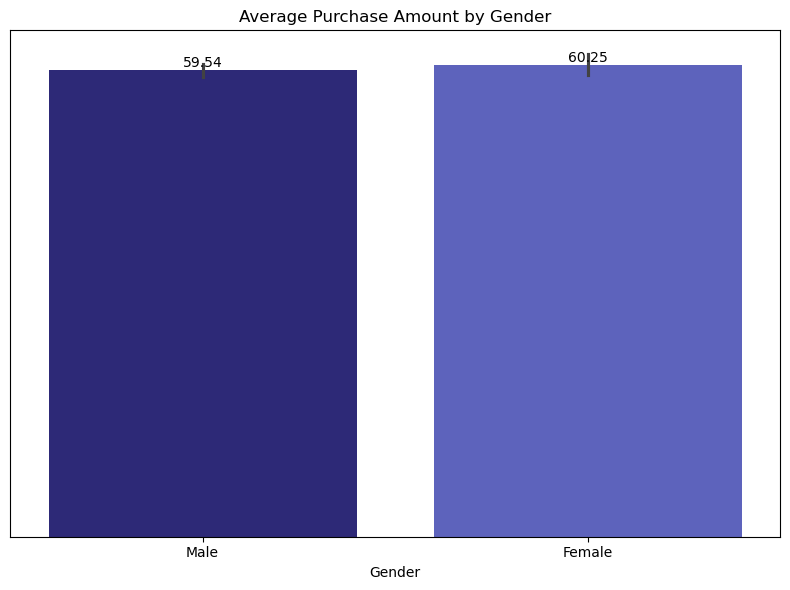

In [39]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=shop, x='gender', y='purchase_amount_usd', palette=custom_colors)
plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('')
ax.yaxis.set_visible(False)

# Data labels
for p in ax.patches:
    value = round(p.get_height(), 2)
    ax.annotate(f'{value}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('avg_purchase_by_gender.png', dpi=300)
plt.show()


# FINDINGS

- On average, female shoppers spent slightly more than their male counterparts, hinting at a marginal but consistent difference in purchase behavior across genders.


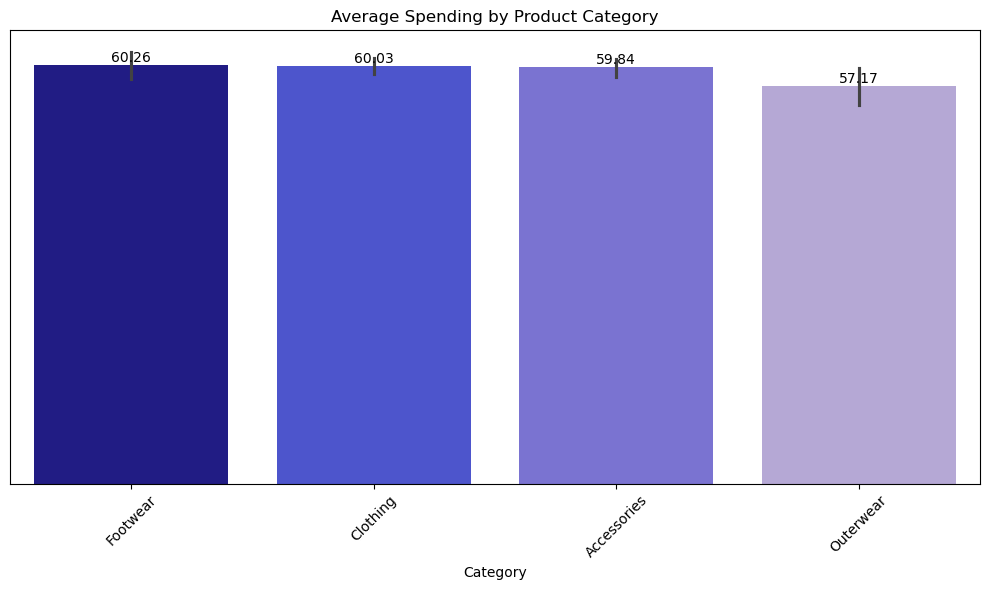

In [40]:
# Custom colors
custom_colors = ['#211C84', '#4D55CC', '#7A73D1', '#B5A8D5']

# Prepare plot
plt.figure(figsize=(10, 6))
order = shop.groupby('category')['purchase_amount_usd'].mean().sort_values(ascending=False).index
ax = sns.barplot(data=shop, x='category', y='purchase_amount_usd', order=order, estimator='mean')

# Apply individual bar colors
for i, patch in enumerate(ax.patches):
    patch.set_facecolor(custom_colors[i % len(custom_colors)])

# Customize
plt.title('Average Spending by Product Category')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylabel('')
ax.yaxis.set_visible(False)

# Add data labels
for p in ax.patches:
    value = round(p.get_height(), 2)
    ax.annotate(f'{value}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('avg_spending_by_category.png', dpi=300)
plt.show()


# Findings

- Footwear led in average spending, suggesting customers are willing to invest more in quality shoes, followed by clothing and accessories, which reflect everyday fashion needs. Outerwear ranked lowest, likely due to its seasonal nature and occasional purchase behavior.

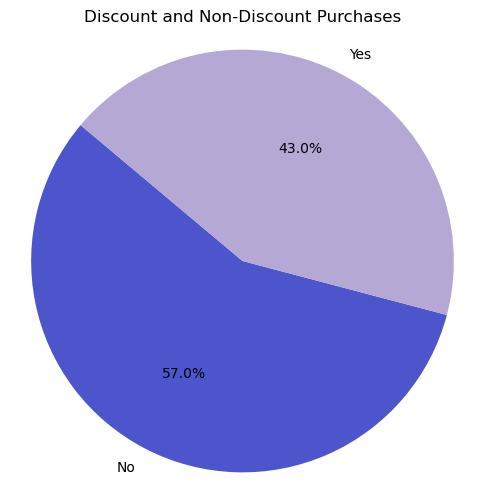

In [102]:
# Custom colors for pie chart
pie_colors = ['#4D55CC', '#B5A8D5']

# Prepare data
plt.figure(figsize=(6, 6))
counts = shop['discount_applied'].value_counts()
labels = counts.index

# Plot pie chart
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=pie_colors)
plt.title('Discount and Non-Discount Purchases')
plt.axis('equal')  # Makes pie chart a circle

# Save plot
plt.savefig('discount_pie_chart.png', dpi=300)
plt.show()


# Findings


- A larger share of purchases were made without discounts, indicating that many customers are willing to pay full price—possibly due to product appeal, urgency, or limited-time availability.

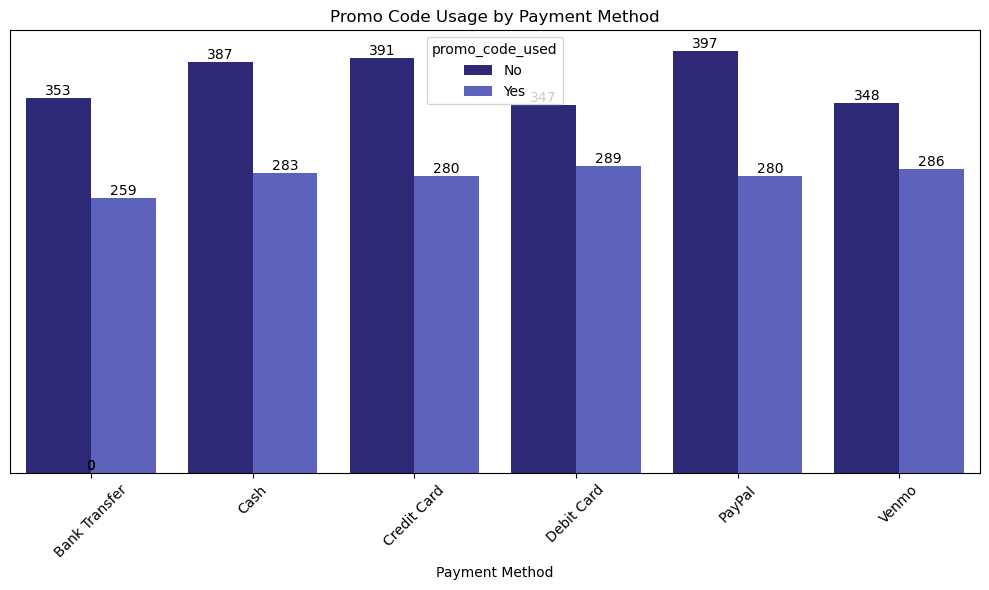

In [190]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=shop, x='payment_method', hue='promo_code_used', palette=custom_colors)
plt.title('Promo Code Usage by Payment Method')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.ylabel('')
ax.yaxis.set_visible(False)

# Add data labels without decimals
for p in ax.patches:
    height = int(p.get_height())  # Cast to integer
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('promo_by_payment.png', dpi=300)
plt.show()


# Findings

- Across all payment methods, including bank transfer, cash, credit card, debit card, PayPal, and Venmo, the majority of purchases were made without using a promo code, suggesting that promo codes are not a primary factor in customer decision-making, regardless of payment preference.

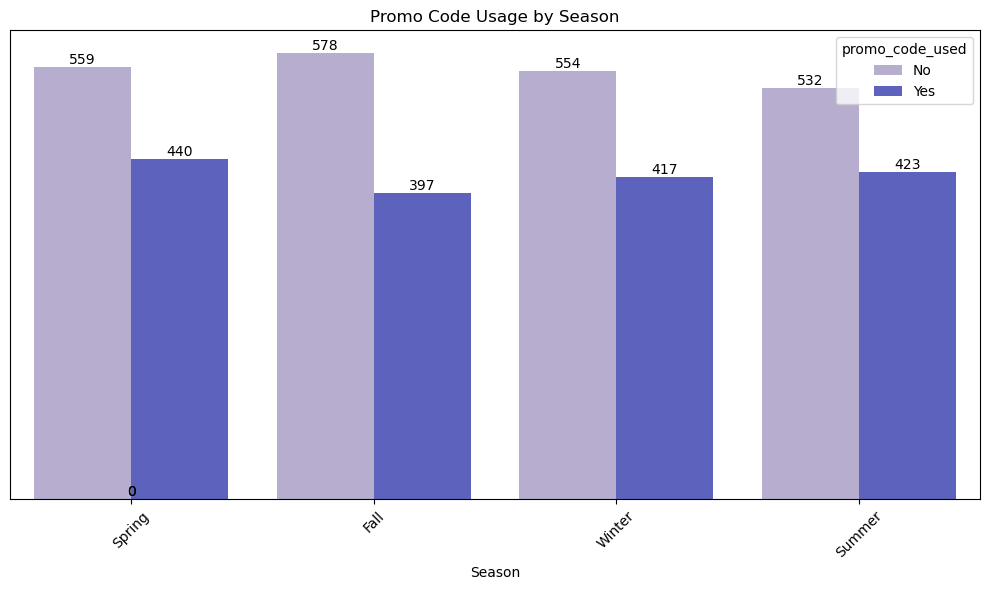

In [116]:
# Define colors for promo code usage
promo_palette = {
    'Yes': '#4D55CC',
    'No':  '#B5A8D5'
}

plt.figure(figsize=(10, 6))
order = shop['season'].value_counts().index

ax = sns.countplot(
    data=shop,
    x='season',
    hue='promo_code_used',
    order=order,
    palette=promo_palette
)

plt.title('Promo Code Usage by Season')
plt.xlabel('Season')
plt.ylabel('')
ax.yaxis.set_visible(False)
plt.xticks(rotation=45)

# Updated labels without decimals
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('promo_code_usage_by_season_clustered.png', dpi=300)
plt.show()


# Findings

- Across all four seasons:Spring, Summer, Fall, and Winter, purchases without promo codes consistently outnumbered those with, suggesting that promotional codes aren’t the primary driver of seasonal buying behavior.

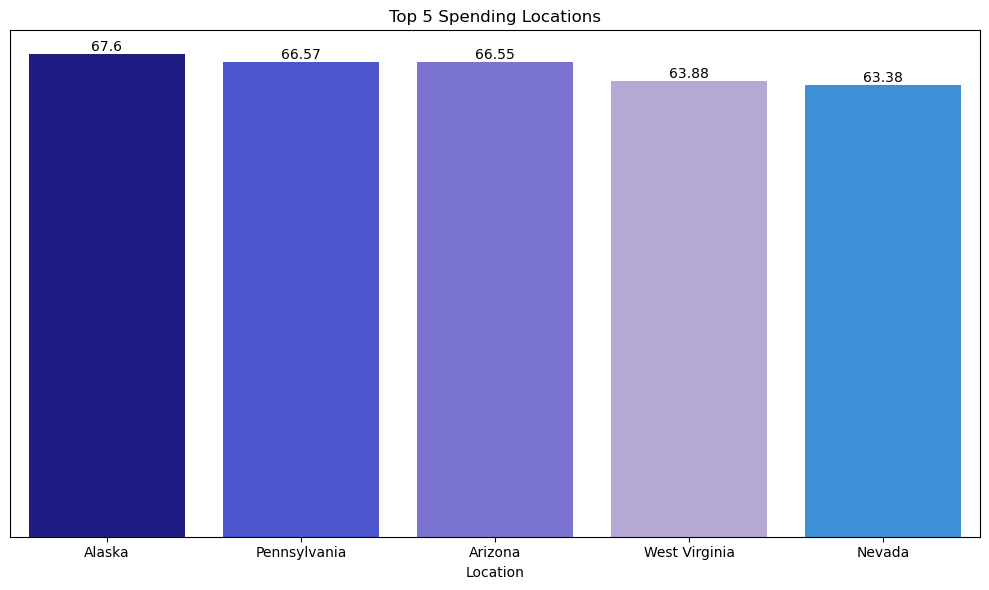

In [195]:
# Average purchase amount by location
# Sort by average spend
top_locs = shop.groupby('location')['purchase_amount_usd'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_locs.index, y=top_locs.values)

# Apply custom bar colors
custom_colors = ['#211C84', '#4D55CC', '#7A73D1', '#B5A8D5', '#3D90D7']
for i, patch in enumerate(ax.patches):
    patch.set_facecolor(custom_colors[i % len(custom_colors)])

# Title and axis
plt.title('Top 5 Spending Locations')
plt.xlabel('Location')
plt.ylabel('')
ax.yaxis.set_visible(False)

# Data labels
for p in ax.patches:
    value = round(p.get_height(), 2)
    ax.annotate(f'{value}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('top_spending_locations.png', dpi=300)
plt.show()


# Findings

- Alaska topped the list for spending, followed closely by Pennsylvania, Arizona, West Virginia, and Nevada, highlighting the diverse regions where customers are willing to make significant purchases.

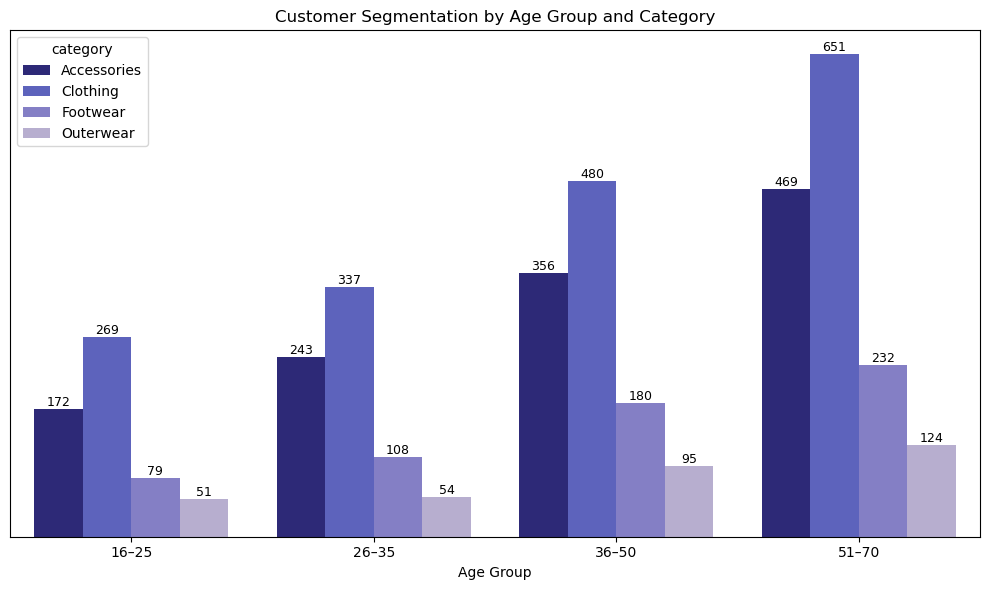

In [132]:
shop['age_group'] = pd.cut(shop['age'].astype(int), bins=[15, 25, 35, 50, 70], labels=['16–25', '26–35', '36–50', '51–70'])

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=shop, x='age_group', hue='category', palette=custom_colors)
plt.title('Customer Segmentation by Age Group and Category')
plt.xlabel('Age Group')
plt.ylabel('')
ax.yaxis.set_visible(False)

# Add integer data labels (no decimals)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('segmentation_by_age.png', dpi=300)
plt.show()


# Findings

- Clothing remained the top choice across all age groups, followed by accessories, footwear, and outerwear, revealing a consistent trend in category preference from young adults (16–25) to older adults (51–70).

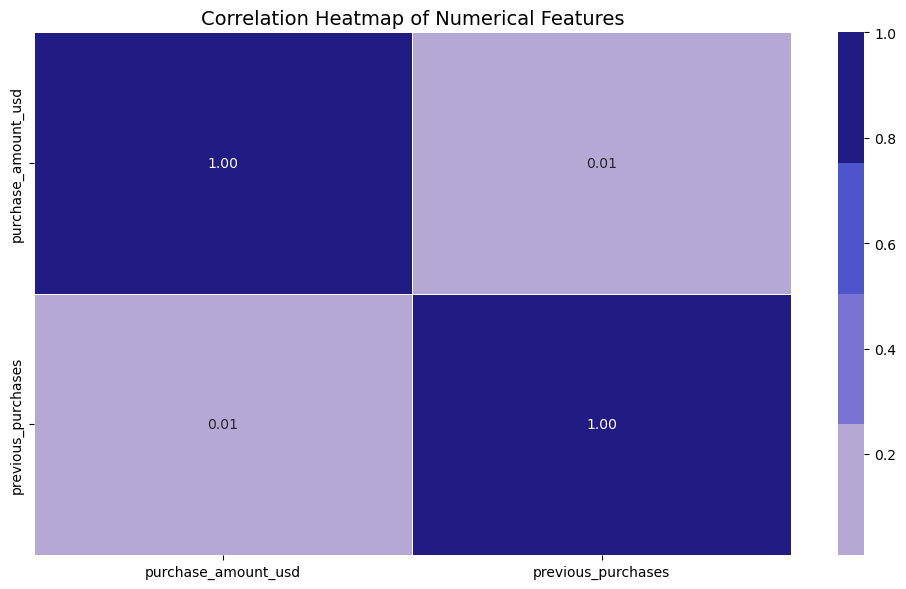

In [161]:
#chaning the datatype of age to int
shop['age'] = shop['age'].astype(int)


# Select only numeric columns
numeric_data = shop.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_data.corr()

# Set up the figure
plt.figure(figsize=(10, 6))

# Create the heatmap
sns.heatmap(
    corr, 
    annot=True, 
    cmap=['#B5A8D5', '#7A73D1', '#4D55CC', '#211C84'], 
    fmt='.2f', 
    linewidths=0.5, 
    linecolor='white'
)

# Title
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)

# Save and show
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()


# Findings


- There is a very weak correlation between each variable, thus, a change in one will not affect the other.

# MACHINE LEARNING

Using Linear Regression

In [58]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: Define features and target
X = shop[['category', 'location', 'season', 'promo_code_used', 'discount_applied', 'previous_purchases', 'payment_method']]
y = shop['purchase_amount_usd']


In [60]:
# Step 2: Preprocess features
# Convert categorical variables using one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['category', 'location', 'season', 'promo_code_used', 'discount_applied', 'payment_method'])
    ])

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [62]:
# Step 4: Define model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Step 5: Train the model
model.fit(X_train, y_train)

# Step 6: Predictions and evaluation
y_pred = model.predict(X_test)

In [65]:
# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R-Squared: {r2}")


Mean Absolute Error: 22.069599880674883
R-Squared: -0.19636665082514337


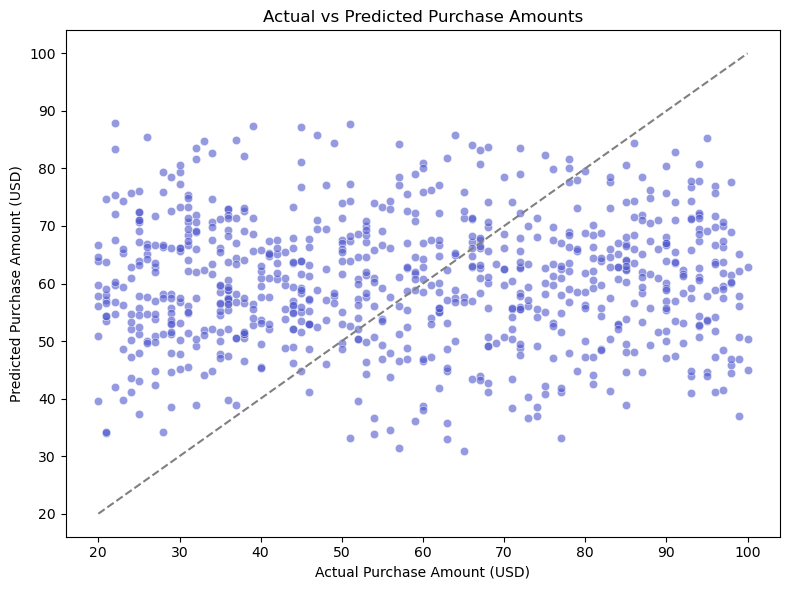

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your actual values
y_true = y_test  # Actual purchase amounts
y_pred = y_pred  # Predicted purchase amounts

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_true, y=y_pred, color='#4D55CC', alpha=0.6)

# Plot a diagonal line for perfect prediction
max_val = max(max(y_true), max(y_pred))
min_val = min(min(y_true), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray')

plt.title('Actual vs Predicted Purchase Amounts')
plt.xlabel('Actual Purchase Amount (USD)')
plt.ylabel('Predicted Purchase Amount (USD)')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()


Using Random Forest Regressor 

In [141]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
X = shop.drop(columns=['purchase_amount_usd'])
y = shop['purchase_amount_usd']


In [143]:
# Get dummy variables for categorical features
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [145]:
# Train Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [146]:
# Predict and evaluate
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R-Squared:", round(r2, 4))

Mean Absolute Error: 20.87
R-Squared: -0.0297


_The R2 score = -0.0297_

Hyperparameter tuning

In [151]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [153]:
# Set up GridSearch
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='r2'
)

# Run GridSearch
grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='r2', verbose=2)

In [154]:
# Best estimator
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

In [155]:
# Evaluate
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Best Parameters:", grid_search.best_params_)
print("Tuned MAE:", round(mae_best, 2))
print("Tuned R-Squared:", round(r2_best, 4))


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Tuned MAE: 20.72
Tuned R-Squared: -0.0028


_After hyperparameter tuning, this random forest regressor gave an R2 score of -0.0028_

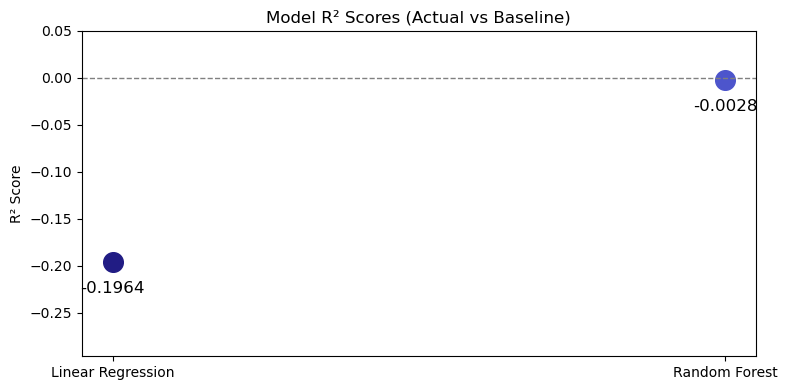

In [173]:
import matplotlib.pyplot as plt

# Model names and their R² scores
models = ['Linear Regression', 'Random Forest']
scores = [-0.19636665082514337, -0.0028]
colors = ['#211C84', '#4D55CC']

plt.figure(figsize=(8, 4))
# Plot the zero baseline
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Scatter the R² scores
for model, score, color in zip(models, scores, colors):
    plt.scatter(model, score, s=200, color=color)

# Annotate each point
for model, score in zip(models, scores):
    plt.text(model, score - 0.02, f'{score:.4f}', 
             ha='center', va='top', fontsize=12)

plt.title('Model R² Scores (Actual vs Baseline)')
plt.ylabel('R² Score')
plt.ylim(min(scores) - 0.1, 0.05)
plt.grid(False)      # Optional: remove grid for cleaner look
plt.tight_layout()
plt.savefig('r2_scores_scatter.png', dpi=300)
plt.show()


# CONCLUSION

- Our analysis revealed clear patterns in customer shopping behavior — with clothing leading in popularity and females slightly outspending males. Promo codes and discounts were underutilized across all payment methods and seasons, indicating room for more strategic marketing efforts. While our attempt to predict purchase amounts using machine learning showed limited success, it highlighted the need for richer data to improve model performance. Together, the insights and modeling offer a strong foundation for smarter decision-making and future data-driven strategies.